# Titanic Survival Analysis — ABRAR JAWAD — May 2026

Problem Statement — 
1. Overall survival rate — what % survived?
2. Survival by Sex — bar chart + chi-square test 
3. Survival by Pclass — bar chart + chi-square test
4. Age distribution — histogram, compare survivors vs non-survivors; t-test on mean age
5. Fare vs Survival — boxplot
6. Correlation heatmap — numeric columns

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [33]:
df = pd.read_csv('../data/raw/train.csv')
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### Part 1: Overall survival rate — what % survived?

In [34]:
survival_rate = df['Survived'].mean()
print(f"Survival rate: {survival_rate:.2%}")

Survival rate: 38.38%


Overall survival rate was 38.38% — meaning 61.62% of passengers did not survive.

### Part 2: Survival by Sex — bar chart + chi-square test 

In [35]:
survival_by_sex = df.groupby('Sex')['Survived'].mean()
print(survival_by_sex)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


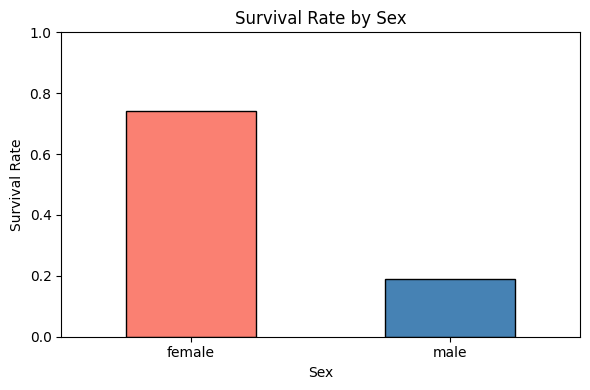

In [36]:
plt.figure(figsize=(6,4))
survival_by_sex.plot(kind='bar', color=['salmon', 'steelblue'], edgecolor='black')
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.tight_layout()
plt.savefig('../visuals/survival_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
contingency = pd.crosstab(df['Sex'], df['Survived'])
print(contingency)

chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"chi2 stat : {chi2:.2f}")
print(f"p-value : {p:.4f}")
print(f"degrees of freedom : {dof}")

Survived    0    1
Sex               
female     81  233
male      468  109
chi2 stat : 260.72
p-value : 0.0000
degrees of freedom : 1


In [38]:
if (p<0.05):
    print("Sex and survival are significantly associated.")
else:
    print("No significant association between sex and survival.")

Sex and survival are significantly associated.


Chi-square test: χ²=260.72, p≈0.000, dof=1
Sex and survival are NOT independent.
Females had a significantly higher survival rate than males.
This aligns with the "women and children first" evacuation protocol.

### Part 3: Survival by Pclass — bar chart + chi-square test 

In [39]:
survival_by_pclass = df.groupby('Pclass')['Survived'].mean()
print(survival_by_pclass)

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


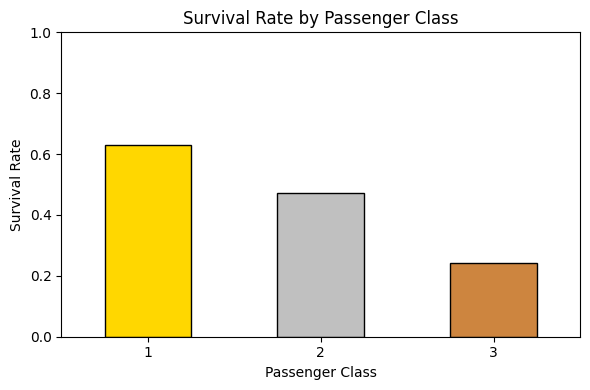

In [40]:
plt.figure(figsize=(6,4))
survival_by_pclass.plot(kind='bar', color=['gold', 'silver', 'peru'], edgecolor='black')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.tight_layout()
plt.savefig('../visuals/survival_by_pclass.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
contingency2 = pd.crosstab(df['Pclass'], df['Survived'])
print(contingenpd2)

chi2, p, dof, expected = stats.chi2_contingency(contingency2)
print(f"chi2 stat : {chi2:.2f}")
print(f"p-value : {p:.4f}")
print(f"degrees of freedom : {dof}")

NameError: name 'contingenpd2' is not defined

In [ ]:
if (p<0.05):
        print("Passenger Class and survival are significantly associated.")
else:
        print("No significant association between Passenger class and survival.")

Chi-square test: χ²=102.89, p≈0.000, dof=2
Passenger class and survival are NOT independent.
Class 1 passengers had a significantly higher survival rate than the other two classes.
This aligns with the "class 1 passengers first" evacuation protocol.